In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score,cross_validate,cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

In [2]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.max_colWidth',None)

In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
submission = pd.read_csv('sample_submission.csv')

In [4]:
df = train.copy()

In [5]:
df = df.drop(columns=['id'])

In [6]:
encoder = LabelEncoder()
df['Heart Disease'] = encoder.fit_transform(df['Heart Disease'])

In [7]:
df.sample(5)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
161496,52,1,4,102,243,0,2,155,0,0.0,2,1,3,0
286218,63,1,3,120,201,0,0,170,0,0.0,1,0,3,0
126216,54,1,2,160,229,0,0,154,0,0.6,1,0,3,0
342534,67,1,3,130,265,0,2,162,0,0.0,2,0,3,0
229236,54,1,4,128,245,0,0,147,0,0.0,1,0,3,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      630000 non-null  int64  
 1   Sex                      630000 non-null  int64  
 2   Chest pain type          630000 non-null  int64  
 3   BP                       630000 non-null  int64  
 4   Cholesterol              630000 non-null  int64  
 5   FBS over 120             630000 non-null  int64  
 6   EKG results              630000 non-null  int64  
 7   Max HR                   630000 non-null  int64  
 8   Exercise angina          630000 non-null  int64  
 9   ST depression            630000 non-null  float64
 10  Slope of ST              630000 non-null  int64  
 11  Number of vessels fluro  630000 non-null  int64  
 12  Thallium                 630000 non-null  int64  
 13  Heart Disease            630000 non-null  int64  
dtypes: f

In [9]:
df.to_csv('train_cleaned.csv',index=False)

In [10]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873,0.448340
std,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007,0.497324
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000,0.000000
75%,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [11]:
df.corr()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
Age,1.000000,0.088397,0.109453,-0.003960,0.019485,0.013354,0.057431,-0.097542,0.110153,0.103064,0.096337,0.102758,0.150124,0.212091
Sex,0.088397,1.000000,0.195893,-0.003355,0.038373,0.020333,0.093590,-0.176186,0.192705,0.181093,0.169854,0.174700,0.275282,0.342446
Chest pain type,0.109453,0.195893,1.000000,-0.003587,0.045463,0.023036,0.120907,-0.221806,0.246211,0.240228,0.233849,0.236787,0.319887,0.460684
BP,-0.003960,-0.003355,-0.003587,1.000000,-0.004597,-0.000784,-0.003738,0.004391,-0.003295,-0.004024,-0.003203,-0.003143,-0.005884,-0.005181
Cholesterol,0.019485,0.038373,0.045463,-0.004597,1.000000,0.006212,0.024948,-0.048575,0.049774,0.044678,0.040197,0.048800,0.061817,0.082753
FBS over 120,0.013354,0.020333,0.023036,-0.000784,0.006212,1.000000,0.016258,-0.024895,0.027971,0.031324,0.030327,0.025691,0.032895,0.033570
EKG results,0.057431,0.093590,0.120907,-0.003738,0.024948,0.016258,1.000000,-0.125047,0.128814,0.149273,0.144468,0.130943,0.169017,0.218961
Max HR,-0.097542,-0.176186,-0.221806,0.004391,-0.048575,-0.024895,-0.125047,1.000000,-0.236232,-0.229462,-0.206190,-0.236319,-0.306912,-0.440985
Exercise angina,0.110153,0.192705,0.246211,-0.003295,0.049774,0.027971,0.128814,-0.236232,1.000000,0.281298,0.245243,0.270413,0.357076,0.441864
ST depression,0.103064,0.181093,0.240228,-0.004024,0.044678,0.031324,0.149273,-0.229462,0.281298,1.000000,0.438240,0.293642,0.316891,0.430641


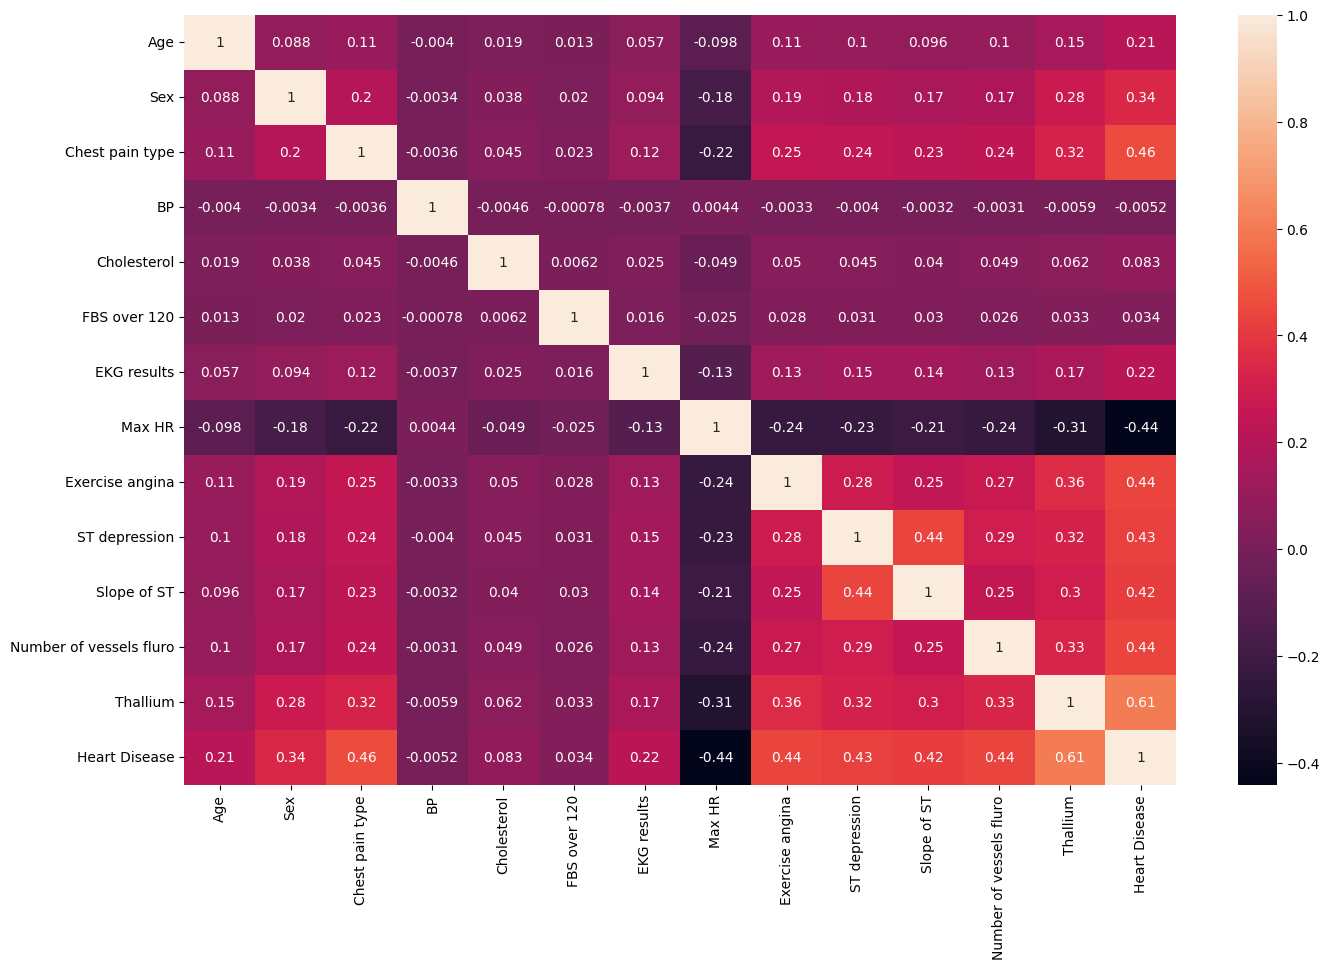

In [12]:
plt.figure(figsize=(16,10))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [12]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=12)
scalar = StandardScaler()
x1 = scalar.fit_transform(x)
x_train1 = scalar.fit_transform(x_train)
x_test1 = scalar.transform(x_test)

# 1. Logistic Regression

In [53]:
lr1 = LogisticRegression(max_iter=1000,n_jobs=-1)
lr1.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [21]:
y_pred1 = lr1.predict(x_test)
y_proba1 = lr1.predict_proba(x_test)[:,1]

In [30]:
print('Accuracy :',np.round(accuracy_score(y_test,y_pred1),3))
print('Precision :',np.round(precision_score(y_test,y_pred1),3))
print("Recall :",np.round(recall_score(y_test,y_pred1),3))
print('f1_score :',np.round(f1_score(y_test,y_pred1),3))
print('roc_auc :',np.round(roc_auc_score(y_test,y_proba1),3))

Accuracy : 0.883
Precision : 0.881
Recall : 0.856
f1_score : 0.868
roc_auc : 0.951


In [33]:
lr2 = LogisticRegression(max_iter=1000,n_jobs=-1,class_weight='balanced')
lr2.fit(x_train,y_train)
y_pred1 = lr2.predict(x_test)
y_proba1 = lr2.predict_proba(x_test)[:,1]
print('Accuracy :',np.round(accuracy_score(y_test,y_pred1),3))
print('Precision :',np.round(precision_score(y_test,y_pred1),3))
print("Recall :",np.round(recall_score(y_test,y_pred1),3))
print('f1_score :',np.round(f1_score(y_test,y_pred1),3))
print('roc_auc :',np.round(roc_auc_score(y_test,y_proba1),3))

Accuracy : 0.883
Precision : 0.866
Recall : 0.873
f1_score : 0.87
roc_auc : 0.951


In [34]:
lr3 = LogisticRegression(max_iter=1000,n_jobs=-1,class_weight={1:8,0:5})
lr3.fit(x_train,y_train)
y_pred1 = lr3.predict(x_test)
y_proba1 = lr3.predict_proba(x_test)[:,1]
print('Accuracy :',np.round(accuracy_score(y_test,y_pred1),3))
print('Precision :',np.round(precision_score(y_test,y_pred1),3))
print("Recall :",np.round(recall_score(y_test,y_pred1),3))
print('f1_score :',np.round(f1_score(y_test,y_pred1),3))
print('roc_auc :',np.round(roc_auc_score(y_test,y_proba1),3))

Accuracy : 0.88
Precision : 0.847
Recall : 0.893
f1_score : 0.869
roc_auc : 0.951


In [37]:
lr4 = LogisticRegression(max_iter=1000,n_jobs=-1,class_weight={1:8,0:5},warm_start=True,penalty='l1',solver='saga')
lr4.fit(x_train,y_train)
y_pred1 = lr4.predict(x_test)
y_proba1 = lr4.predict_proba(x_test)[:,1]
print('Accuracy :',np.round(accuracy_score(y_test,y_pred1),3))
print('Precision :',np.round(precision_score(y_test,y_pred1),3))
print("Recall :",np.round(recall_score(y_test,y_pred1),3))
print('f1_score :',np.round(f1_score(y_test,y_pred1),3))
print('roc_auc :',np.round(roc_auc_score(y_test,y_proba1),3))

Accuracy : 0.88
Precision : 0.847
Recall : 0.893
f1_score : 0.87
roc_auc : 0.951


In [20]:
lr5 = LogisticRegression(max_iter=1000,n_jobs=-1,class_weight={1:8,0:5},warm_start=True,penalty='elasticnet',solver='saga',l1_ratio=0.5)
lr5.fit(x_train,y_train)
y_pred1 = lr5.predict(x_test)
y_proba1 = lr5.predict_proba(x_test)[:,1]
print('Accuracy :',np.round(accuracy_score(y_test,y_pred1),3))
print('Precision :',np.round(precision_score(y_test,y_pred1),3))
print("Recall :",np.round(recall_score(y_test,y_pred1),3))
print('f1_score :',np.round(f1_score(y_test,y_pred1),3))
print('roc_auc :',np.round(roc_auc_score(y_test,y_proba1),3))

Accuracy : 0.88
Precision : 0.847
Recall : 0.893
f1_score : 0.87
roc_auc : 0.951


In [41]:
lr5 = LogisticRegression(max_iter=1000,n_jobs=-1,class_weight={1:8,0:5},warm_start=True,solver='newton-cholesky')
lr5.fit(x_train,y_train)
y_pred1 = lr5.predict(x_test)
y_proba1 = lr5.predict_proba(x_test)[:,1]
print('Accuracy :',np.round(accuracy_score(y_test,y_pred1),3))
print('Precision :',np.round(precision_score(y_test,y_pred1),3))
print("Recall :",np.round(recall_score(y_test,y_pred1),3))
print('f1_score :',np.round(f1_score(y_test,y_pred1),3))
print('roc_auc :',np.round(roc_auc_score(y_test,y_proba1),3))

Accuracy : 0.88
Precision : 0.847
Recall : 0.893
f1_score : 0.869
roc_auc : 0.951


In [42]:
lr5 = LogisticRegression(max_iter=1000,n_jobs=-1,class_weight={1:8,0:5},warm_start=True,solver='newton-cg')
lr5.fit(x_train,y_train)
y_pred1 = lr5.predict(x_test)
y_proba1 = lr5.predict_proba(x_test)[:,1]
print('Accuracy :',np.round(accuracy_score(y_test,y_pred1),3))
print('Precision :',np.round(precision_score(y_test,y_pred1),3))
print("Recall :",np.round(recall_score(y_test,y_pred1),3))
print('f1_score :',np.round(f1_score(y_test,y_pred1),3))
print('roc_auc :',np.round(roc_auc_score(y_test,y_proba1),3))

Accuracy : 0.88
Precision : 0.847
Recall : 0.893
f1_score : 0.869
roc_auc : 0.951


In [43]:
metrics = ['accuracy','precision','recall','f1','roc_auc']
lr12 = LogisticRegression(max_iter=1000,n_jobs=-1,class_weight={1:8,0:5},warm_start=True)
scores = cross_validate(lr12,x,y,cv=10,scoring=metrics,n_jobs=-1,return_train_score=True)
for metric in metrics:
    mean1 = np.mean(scores[f'train_{metric}'])
    mean2 = np.mean(scores[f'test_{metric}'])
    print(f'train_{metric}',np.round(mean1,3),f'test_{metric}',np.round(mean2,3))
    

train_accuracy 0.88 test_accuracy 0.88
train_precision 0.847 test_precision 0.847
train_recall 0.894 test_recall 0.894
train_f1 0.87 test_f1 0.87
train_roc_auc 0.951 test_roc_auc 0.95


In [44]:
metrics = ['accuracy','precision','recall','f1','roc_auc']
lr12 = LogisticRegression(max_iter=1000,n_jobs=-1,class_weight={1:8,0:5},warm_start=True,solver='newton-cholesky')
scores = cross_validate(lr12,x,y,cv=10,scoring=metrics,n_jobs=-1,return_train_score=True)
for metric in metrics:
    mean1 = np.mean(scores[f'train_{metric}'])
    mean2 = np.mean(scores[f'test_{metric}'])
    print(f'train_{metric}',np.round(mean1,3),f'test_{metric}',np.round(mean2,3))

train_accuracy 0.88 test_accuracy 0.88
train_precision 0.847 test_precision 0.847
train_recall 0.894 test_recall 0.894
train_f1 0.87 test_f1 0.87
train_roc_auc 0.951 test_roc_auc 0.951


In [13]:
metrics = ['accuracy','precision','recall','f1','roc_auc']
lr12 = LogisticRegression(max_iter=1000,n_jobs=-1,class_weight={1:8,0:5},warm_start=True,solver='newton-cg')
scores = cross_validate(lr12,x,y,cv=10,scoring=metrics,n_jobs=-1,return_train_score=True)
for metric in metrics:
    mean1 = np.mean(scores[f'train_{metric}'])
    mean2 = np.mean(scores[f'test_{metric}'])
    print(f'train_{metric}',np.round(mean1,3),f'test_{metric}',np.round(mean2,3))

train_accuracy 0.88 test_accuracy 0.88
train_precision 0.847 test_precision 0.847
train_recall 0.894 test_recall 0.894
train_f1 0.87 test_f1 0.87
train_roc_auc 0.951 test_roc_auc 0.951


In [47]:
import joblib
joblib.dump(lr12,'LR1.pkl')

['LR1.pkl']

In [21]:
import pickle
data_to_save = {'model':'LogisticRegression','Accuracy':0.88,'roc_auc':0.95}

with open('model_lr.pkl','wb') as file:
    pickle.dump(lr5,file)

## SGD Classifier

In [27]:
x_train.sample(5)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
166276,57,1,3,125,260,0,2,132,1,1.6,2,1,7
334862,61,0,3,102,211,0,2,168,0,0.0,2,0,3
513396,59,0,3,150,303,0,0,178,0,0.0,2,0,3
547651,65,0,3,120,274,0,0,163,0,1.0,2,0,3
190947,35,1,3,128,211,0,2,163,0,0.0,1,0,3


In [31]:
x_train['Thallium'].unique()

array([7, 3, 6])

In [32]:
x_train.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium'],
      dtype='object')

In [ ]:
import shap
explainer = shap.Explainer(lr1.predict,x_train)
shap_values = explainer(x_train)

shap.plots.waterfall(shap_values[0])

PermutationExplainer explainer:   0%|                                           | 265/504000 [00:27<6:13:37, 22.47it/s]